In [2]:
# Part 3 – Machine Learning and AI
## Smart City Traffic Intelligence

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

logger = logging.getLogger(__name__)

In [3]:
df = pd.read_csv("data/traffic_features.csv")

print(df.shape)
df.head()

(48187, 28)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day_of_week,...,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm,temp_scaled,traffic_volume_scaled,congestion_category
0,NaN,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,...,0,0,0,0,0,0,0,0.673215,0.761676,High
1,NaN,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,...,0,0,0,0,0,0,0,0.689412,0.620330,Medium
2,NaN,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,...,0,0,0,0,0,0,0,0.692711,0.654808,Medium
3,NaN,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,...,0,0,0,0,0,0,0,0.700960,0.690385,High
4,NaN,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,...,0,0,0,0,0,0,0,0.716107,0.675549,Medium


In [4]:
df.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_description',
 'date_time',
 'traffic_volume',
 'hour',
 'day_of_week',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'adverse_weather',
 'weather_Clear',
 'weather_Clouds',
 'weather_Drizzle',
 'weather_Fog',
 'weather_Haze',
 'weather_Mist',
 'weather_Rain',
 'weather_Smoke',
 'weather_Snow',
 'weather_Squall',
 'weather_Thunderstorm',
 'temp_scaled',
 'traffic_volume_scaled',
 'congestion_category']

In [5]:
q1, q2, q3 = df["traffic_volume"].quantile([0.25, 0.50, 0.75])

def congestion_bucket(value):
    if value <= q1:
        return "Low"
    elif value <= q2:
        return "Medium"
    elif value <= q3:
        return "High"
    else:
        return "Severe"

df["congestion_category_p3"] = df["traffic_volume"].apply(congestion_bucket)

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

print("\nCongestion categories:")
print(df["congestion_category_p3"].value_counts())

Q1: 1192.5
Q2: 3379.0
Q3: 4933.0

Congestion categories:
congestion_category_p3
High      12054
Medium    12049
Low       12047
Severe    12037
Name: count, dtype: int64


In [6]:
risky_weather_columns = [
    "weather_Drizzle",
    "weather_Fog",
    "weather_Haze",
    "weather_Mist",
    "weather_Rain",
    "weather_Smoke",
    "weather_Snow",
    "weather_Squall",
    "weather_Thunderstorm"
]

high_congestion = df["congestion_category_p3"].isin(["High", "Severe"])

risky_weather = df[risky_weather_columns].eq(1).any(axis=1)

df["proxy_accident_risk"] = (
    high_congestion & risky_weather
).astype(int)

print(df["proxy_accident_risk"].value_counts())

print("\nPercentage:")
print(df["proxy_accident_risk"].value_counts(normalize=True) * 100)

proxy_accident_risk
0    38905
1     9282
Name: count, dtype: int64

Percentage:
proxy_accident_risk
0    80.737543
1    19.262457
Name: proportion, dtype: float64


In [7]:
classification_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "temp_scaled",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "adverse_weather",
    "weather_Clear",
    "weather_Clouds",
    "weather_Drizzle",
    "weather_Fog",
    "weather_Haze",
    "weather_Mist",
    "weather_Rain",
    "weather_Smoke",
    "weather_Snow",
    "weather_Squall",
    "weather_Thunderstorm"
]

X_class = df[classification_features]
y_class = df["proxy_accident_risk"]

print("Features shape:", X_class.shape)
print("Target shape:", y_class.shape)

Features shape: (48187, 21)
Target shape: (48187,)


In [8]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training rows:", len(X_train_c))
print("Testing rows:", len(X_test_c))

Training rows: 38549
Testing rows: 9638


In [9]:
df["day_of_week"].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

In [10]:
df["date_time"] = pd.to_datetime(df["date_time"])

df["day_of_week_num"] = df["date_time"].dt.dayofweek

df[["date_time", "day_of_week", "day_of_week_num"]].head()

,date_time,day_of_week,day_of_week_num
0,2012-10-02 09:00:00,Tuesday,1
1,2012-10-02 10:00:00,Tuesday,1
2,2012-10-02 11:00:00,Tuesday,1
3,2012-10-02 12:00:00,Tuesday,1
4,2012-10-02 13:00:00,Tuesday,1


In [11]:
classification_features = [
    "hour",
    "day_of_week_num",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "temp_scaled",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "adverse_weather",
    "weather_Clear",
    "weather_Clouds",
    "weather_Drizzle",
    "weather_Fog",
    "weather_Haze",
    "weather_Mist",
    "weather_Rain",
    "weather_Smoke",
    "weather_Snow",
    "weather_Squall",
    "weather_Thunderstorm"
]

X_class = df[classification_features]
y_class = df["proxy_accident_risk"]

print(X_class.dtypes)

hour                      int64
day_of_week_num           int32
is_weekend                int64
hour_sin                float64
hour_cos                float64
temp_scaled             float64
rain_1h                 float64
snow_1h                 float64
clouds_all                int64
adverse_weather           int64
weather_Clear             int64
weather_Clouds            int64
weather_Drizzle           int64
weather_Fog               int64
weather_Haze              int64
weather_Mist              int64
weather_Rain              int64
weather_Smoke             int64
weather_Snow              int64
weather_Squall            int64
weather_Thunderstorm      int64
dtype: object


In [12]:
print("Non-numeric columns:")
print(X_class.select_dtypes(exclude=np.number).columns.tolist())

Non-numeric columns:
[]


In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training rows:", len(X_train_c))
print("Testing rows:", len(X_test_c))

Training rows: 38549
Testing rows: 9638


In [14]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_c, y_train_c)

log_pred = log_model.predict(X_test_c)
log_prob = log_model.predict_proba(X_test_c)[:, 1]

In [15]:
log_accuracy = accuracy_score(y_test_c, log_pred)
log_precision = precision_score(y_test_c, log_pred, zero_division=0)
log_recall = recall_score(y_test_c, log_pred, zero_division=0)
log_f1 = f1_score(y_test_c, log_pred, zero_division=0)
log_auc = roc_auc_score(y_test_c, log_prob)

print("Logistic Regression")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1-score:", round(log_f1, 4))
print("ROC AUC:", round(log_auc, 4))

Logistic Regression
Accuracy: 0.9565
Precision: 0.8227
Recall: 0.9871
F1-score: 0.8974
ROC AUC: 0.9913


In [16]:
rf_class_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_class_model.fit(X_train_c, y_train_c)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [17]:
rf_pred = rf_class_model.predict(X_test_c)
rf_prob = rf_class_model.predict_proba(X_test_c)[:, 1]

In [18]:
rf_accuracy = accuracy_score(y_test_c, rf_pred)
rf_precision = precision_score(y_test_c, rf_pred, zero_division=0)
rf_recall = recall_score(y_test_c, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test_c, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test_c, rf_prob)

print("Random Forest Classifier")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))
print("ROC AUC:", round(rf_auc, 4))

Random Forest Classifier
Accuracy: 0.9786
Precision: 0.9089
Recall: 0.9882
F1-score: 0.9469
ROC AUC: 0.9969


In [19]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        rf_recall
    ],
    "F1-score": [
        log_f1,
        rf_f1
    ],
    "ROC AUC": [
        log_auc,
        rf_auc
    ]
})

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.9565,0.8227,0.9871,0.8974,0.9913
1,Random Forest,0.9786,0.9089,0.9882,0.9469,0.9969


In [20]:
regression_features = [
    "hour",
    "day_of_week_num",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "temp_scaled",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "adverse_weather",
    "weather_Clear",
    "weather_Clouds",
    "weather_Drizzle",
    "weather_Fog",
    "weather_Haze",
    "weather_Mist",
    "weather_Rain",
    "weather_Smoke",
    "weather_Snow",
    "weather_Squall",
    "weather_Thunderstorm"
]

X_reg = df[regression_features]
y_reg = df["traffic_volume"]

In [21]:
print("Regression features:", X_reg.shape)
print("Regression target:", y_reg.shape)

print("\nNon-numeric columns:")
print(X_reg.select_dtypes(exclude=np.number).columns.tolist())

Regression features: (48187, 21)
Regression target: (48187,)

Non-numeric columns:
[]


In [22]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_r))
print("Testing rows:", len(X_test_r))

Training rows: 38549
Testing rows: 9638


In [23]:
linear_model = LinearRegression()

linear_model.fit(X_train_r, y_train_r)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 60.83, 62.52,-1188.61,..., -120.08, -285.2 , 24.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['hour','day_of_week_num','is_weekend',...,'weather_Snow','weather_Squall', 'weather_Thunderstorm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2563
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,19


In [24]:
linear_pred = linear_model.predict(X_test_r)

In [25]:
linear_mae = mean_absolute_error(y_test_r, linear_pred)
linear_r2 = r2_score(y_test_r, linear_pred)

print("Linear Regression")
print("MAE:", round(linear_mae, 2))
print("R-squared:", round(linear_r2, 4))

Linear Regression
MAE: 820.38
R-squared: 0.722


In [26]:
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_reg_model.fit(X_train_r, y_train_r)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [27]:
rf_reg_pred = rf_reg_model.predict(X_test_r)

In [28]:
rf_reg_mae = mean_absolute_error(y_test_r, rf_reg_pred)
rf_reg_r2 = r2_score(y_test_r, rf_reg_pred)

print("Random Forest Regressor")
print("MAE:", round(rf_reg_mae, 2))
print("R-squared:", round(rf_reg_r2, 4))

Random Forest Regressor
MAE: 266.72
R-squared: 0.9469


In [29]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae
    ],
    "R-squared": [
        linear_r2,
        rf_reg_r2
    ]
})

regression_results.round(4)

,Model,MAE,R-squared
0,Linear Regression,820.3828,0.7220
1,Random Forest,266.7202,0.9469


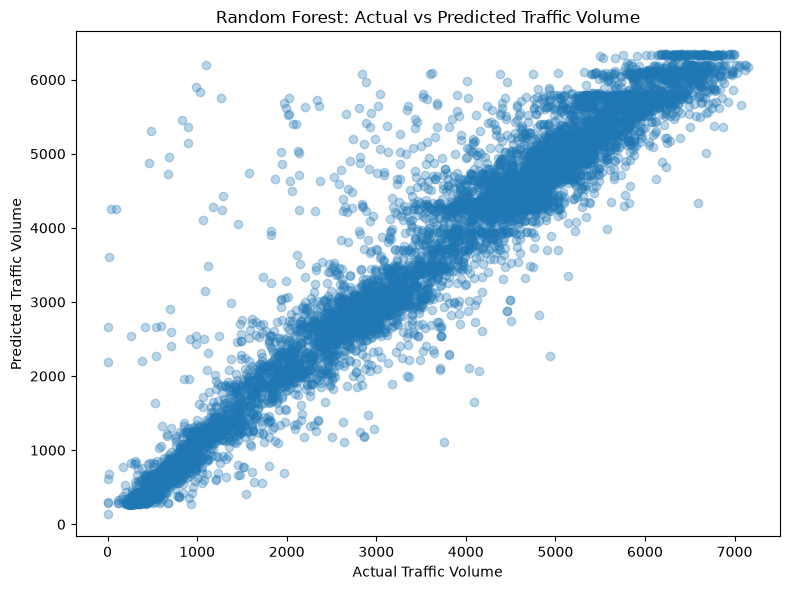

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_r,
    rf_reg_pred,
    alpha=0.3
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Random Forest: Actual vs Predicted Traffic Volume")

plt.tight_layout()
plt.show()

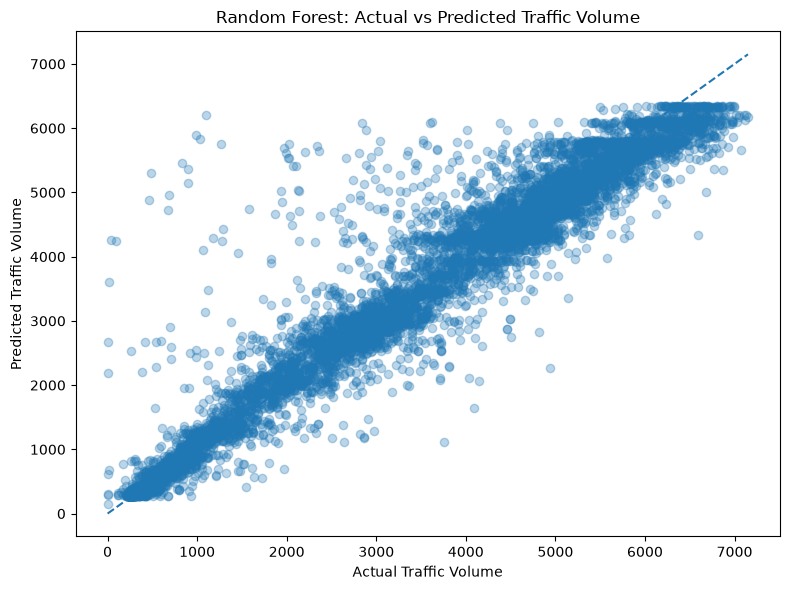

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_r,
    rf_reg_pred,
    alpha=0.3
)

minimum = min(y_test_r.min(), rf_reg_pred.min())
maximum = max(y_test_r.max(), rf_reg_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Random Forest: Actual vs Predicted Traffic Volume")

plt.tight_layout()
plt.show()

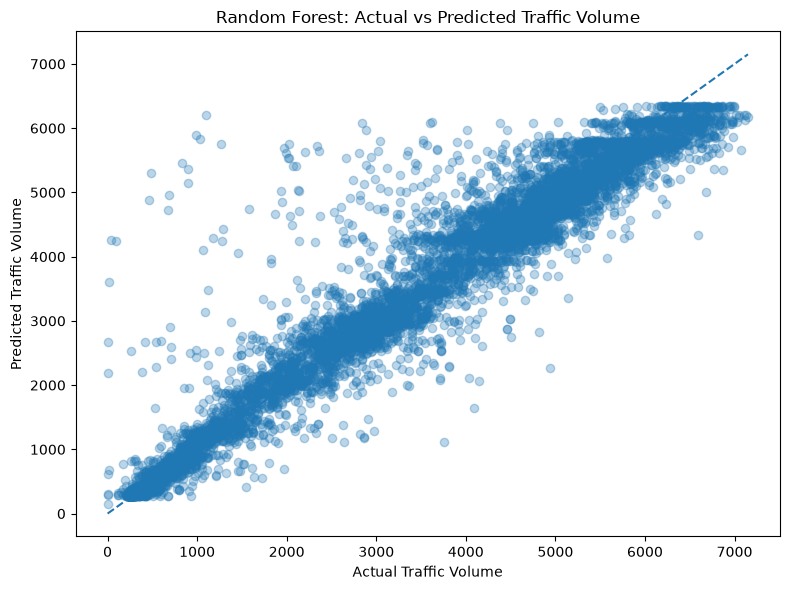

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_r,
    rf_reg_pred,
    alpha=0.3
)

minimum = min(y_test_r.min(), rf_reg_pred.min())
maximum = max(y_test_r.max(), rf_reg_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Random Forest: Actual vs Predicted Traffic Volume")

plt.tight_layout()
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": regression_features,
    "Importance": rf_reg_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,hour_cos,0.676196
0,hour,0.142960
1,day_of_week_num,0.061950
3,hour_sin,0.054437
2,is_weekend,0.045148
5,temp_scaled,0.013265
6,rain_1h,0.001810
8,clouds_all,0.001420
9,adverse_weather,0.001031
13,weather_Fog,0.000486


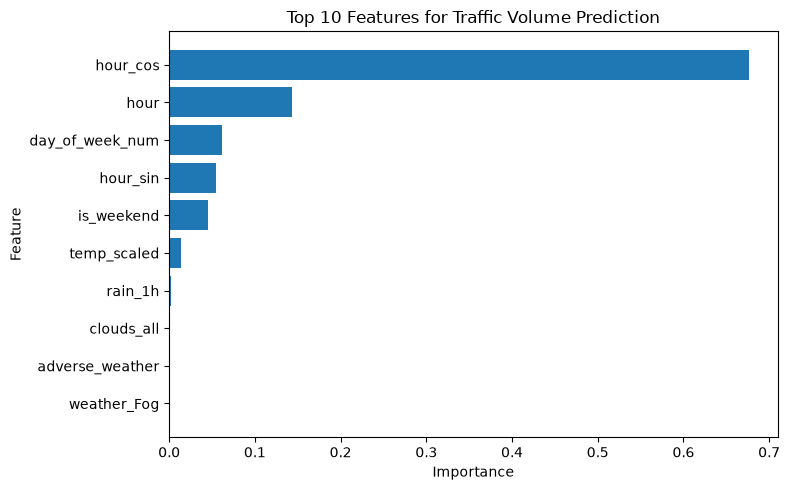

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Traffic Volume Prediction")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
import joblib
from pathlib import Path

In [36]:
Path("models").mkdir(exist_ok=True)

In [37]:
joblib.dump(
    log_model,
    "models/logistic_classification.pkl"
)

joblib.dump(
    rf_class_model,
    "models/random_forest_classification.pkl"
)

joblib.dump(
    linear_model,
    "models/linear_regression.pkl"
)

joblib.dump(
    rf_reg_model,
    "models/random_forest_regression.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [38]:
## Task 2: Unsupervised Machine Learning
### 2.1 K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
cluster_features = [
    "hour",
    "adverse_weather",
    "traffic_volume"
]

X_cluster = df[cluster_features].copy()

X_cluster.head()

,hour,adverse_weather,traffic_volume
0,9,0,5545
1,10,0,4516
2,11,0,4767
3,12,0,5026
4,13,0,4918


In [40]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print(X_cluster_scaled[:5])

[[-0.34548099 -0.78129407  1.15020531]
 [-0.20139502 -0.78129407  0.63232194]
 [-0.05730906 -0.78129407  0.75864723]
 [ 0.08677691 -0.78129407  0.88899883]
 [ 0.23086287 -0.78129407  0.83464372]]


In [41]:
inertia_values = []

k_values = range(2, 9)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_cluster_scaled)
    inertia_values.append(model.inertia_)

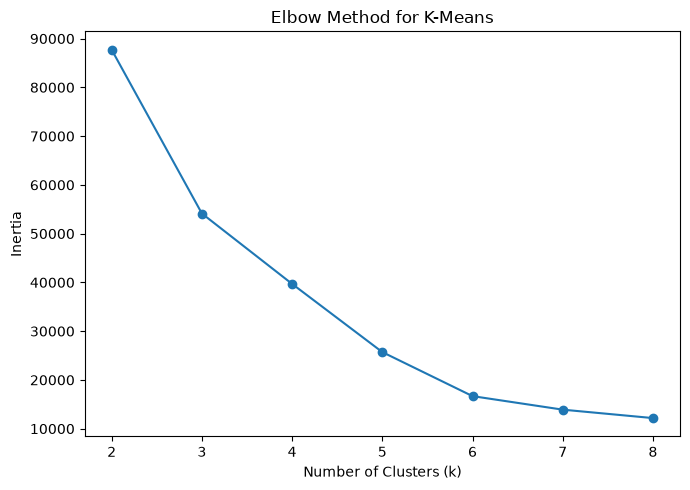

In [42]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [43]:
silhouette_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_cluster_scaled)

    score = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_results.append({
        "k": k,
        "Silhouette Score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)

silhouette_df.round(4)

,k,Silhouette Score
0,2,0.4199
1,3,0.4869
2,4,0.5471
3,5,0.5615
4,6,0.5980
5,7,0.5479
6,8,0.5225


In [44]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans_final.fit_predict(
    X_cluster_scaled
)

df["cluster"].value_counts().sort_index()

cluster
0    12096
1     8127
2    21795
3     6169
Name: count, dtype: int64

In [45]:
cluster_summary = df.groupby("cluster")[
    ["hour", "adverse_weather", "traffic_volume"]
].mean()

cluster_summary["count"] = (
    df["cluster"].value_counts().sort_index()
)

cluster_summary.round(2)

,hour,adverse_weather,traffic_volume,count
cluster,,,,
0,14.37,1.0,4199.78,12096
1,3.09,0.0,926.38,8127
2,15.14,0.0,4268.72,21795
3,3.28,1.0,924.83,6169


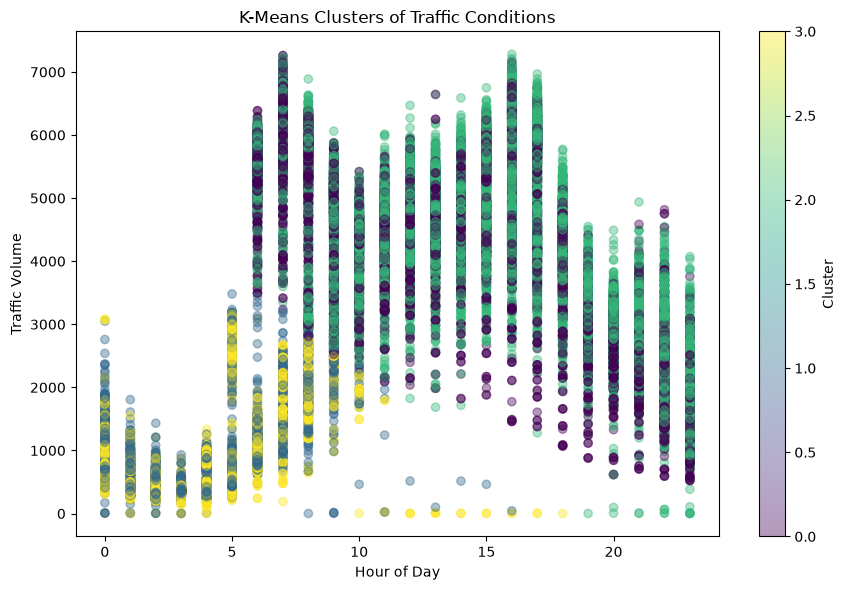

In [46]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["hour"],
    df["traffic_volume"],
    c=df["cluster"],
    alpha=0.4
)

plt.xlabel("Hour of Day")
plt.ylabel("Traffic Volume")
plt.title("K-Means Clusters of Traffic Conditions")

plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [47]:
pip install --user mlxtend

Note: you may need to restart the kernel to use updated packages.


In [48]:
from mlxtend.frequent_patterns import apriori, association_rules

In [49]:
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(get_time_period)

df["time_period"].value_counts()

time_period
Night        16234
Morning      14353
Afternoon     9748
Evening       7852
Name: count, dtype: int64

In [50]:
df["day_type"] = df["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

df["day_type"].value_counts()

day_type
Weekday    34487
Weekend    13700
Name: count, dtype: int64

In [51]:
df["weather_type"] = df["adverse_weather"].map({
    0: "Normal_Weather",
    1: "Adverse_Weather"
})

df["weather_type"].value_counts()

weather_type
Normal_Weather     29922
Adverse_Weather    18265
Name: count, dtype: int64

In [52]:
df["congestion_category_p3"].value_counts()

congestion_category_p3
High      12054
Medium    12049
Low       12047
Severe    12037
Name: count, dtype: int64

In [53]:
association_data = df[
    [
        "time_period",
        "day_type",
        "weather_type",
        "congestion_category_p3"
    ]
].copy()

association_data.head()

,time_period,day_type,weather_type,congestion_category_p3
0,Morning,Weekday,Normal_Weather,Severe
1,Morning,Weekday,Normal_Weather,High
2,Morning,Weekday,Normal_Weather,High
3,Afternoon,Weekday,Normal_Weather,Severe
4,Afternoon,Weekday,Normal_Weather,High


In [54]:
association_data["time_period"] = (
    "Time=" + association_data["time_period"]
)

association_data["day_type"] = (
    "Day=" + association_data["day_type"]
)

association_data["weather_type"] = (
    "Weather=" + association_data["weather_type"]
)

association_data["congestion_category_p3"] = (
    "Congestion=" + association_data["congestion_category_p3"]
)

association_data.head()

,time_period,day_type,weather_type,congestion_category_p3
0,Time=Morning,Day=Weekday,Weather=Normal_Weather,Congestion=Severe
1,Time=Morning,Day=Weekday,Weather=Normal_Weather,Congestion=High
2,Time=Morning,Day=Weekday,Weather=Normal_Weather,Congestion=High
3,Time=Afternoon,Day=Weekday,Weather=Normal_Weather,Congestion=Severe
4,Time=Afternoon,Day=Weekday,Weather=Normal_Weather,Congestion=High


In [55]:
basket = pd.get_dummies(
    association_data,
    prefix="",
    prefix_sep="",
    dtype=bool
)

basket.head()

,Time=Afternoon,Time=Evening,Time=Morning,Time=Night,Day=Weekday,Day=Weekend,Weather=Adverse_Weather,Weather=Normal_Weather,Congestion=High,Congestion=Low,Congestion=Medium,Congestion=Severe
0,False,False,True,False,True,False,False,True,False,False,False,True
1,False,False,True,False,True,False,False,True,True,False,False,False
2,False,False,True,False,True,False,False,True,True,False,False,False
3,True,False,False,False,True,False,False,True,False,False,False,True
4,True,False,False,False,True,False,False,True,True,False,False,False


In [56]:
frequent_itemsets = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
)

frequent_itemsets.head(10)

,support,itemsets
4,0.715691,(Day=Weekday)
7,0.620956,(Weather=Normal_Weather)
37,0.439849,"(Day=Weekday, Weather=Normal_Weather)"
6,0.379044,(Weather=Adverse_Weather)
3,0.336896,(Time=Night)
2,0.297860,(Time=Morning)
5,0.284309,(Day=Weekend)
36,0.275842,"(Weather=Adverse_Weather, Day=Weekday)"
8,0.250150,(Congestion=High)
10,0.250047,(Congestion=Medium)


In [57]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

print("Number of rules:", len(rules))

Number of rules: 224


In [58]:
congestion_rules = rules[
    rules["consequents"].apply(
        lambda x: any(
            str(item).startswith("Congestion=")
            for item in x
        )
    )
].copy()

In [59]:
congestion_rules = congestion_rules.sort_values(
    "lift",
    ascending=False
)

congestion_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
147,"(Weather=Adverse_Weather, Time=Night)","(Congestion=Low, Day=Weekday)",0.072073,0.538951,3.189295
130,"(Day=Weekday, Time=Afternoon)","(Congestion=Severe, Weather=Normal_Weather)",0.073879,0.509883,3.164161
125,"(Day=Weekday, Weather=Normal_Weather, Time=Aft...",(Congestion=Severe),0.073879,0.744926,2.982116
143,"(Weather=Adverse_Weather, Time=Night, Day=Week...",(Congestion=Low),0.072073,0.738465,2.953798
152,(Time=Night),"(Weather=Adverse_Weather, Congestion=Low, Day=...",0.072073,0.213934,2.927811
14,(Time=Night),"(Congestion=Low, Day=Weekday)",0.166476,0.494148,2.924170
92,(Time=Night),"(Congestion=Low, Day=Weekday, Weather=Normal_W...",0.094403,0.280214,2.921395
80,"(Weather=Adverse_Weather, Time=Night)",(Congestion=Low),0.095544,0.714463,2.857793
60,"(Day=Weekday, Time=Afternoon)",(Congestion=Severe),0.103347,0.713263,2.855362
89,"(Time=Night, Day=Weekday)","(Congestion=Low, Weather=Normal_Weather)",0.094403,0.390740,2.757962


In [60]:
top_rules = congestion_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10).copy()

top_rules["antecedents"] = top_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_rules["consequents"] = top_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_rules.round(4)

,antecedents,consequents,support,confidence,lift
147,"Time=Night, Weather=Adverse_Weather","Congestion=Low, Day=Weekday",0.0721,0.5390,3.1893
130,"Day=Weekday, Time=Afternoon","Congestion=Severe, Weather=Normal_Weather",0.0739,0.5099,3.1642
125,"Day=Weekday, Time=Afternoon, Weather=Normal_We...",Congestion=Severe,0.0739,0.7449,2.9821
143,"Day=Weekday, Time=Night, Weather=Adverse_Weather",Congestion=Low,0.0721,0.7385,2.9538
152,Time=Night,"Congestion=Low, Day=Weekday, Weather=Adverse_W...",0.0721,0.2139,2.9278
14,Time=Night,"Congestion=Low, Day=Weekday",0.1665,0.4941,2.9242
92,Time=Night,"Congestion=Low, Day=Weekday, Weather=Normal_We...",0.0944,0.2802,2.9214
80,"Time=Night, Weather=Adverse_Weather",Congestion=Low,0.0955,0.7145,2.8578
60,"Day=Weekday, Time=Afternoon",Congestion=Severe,0.1033,0.7133,2.8554
89,"Day=Weekday, Time=Night","Congestion=Low, Weather=Normal_Weather",0.0944,0.3907,2.7580


In [61]:
## Task 3: Deep Learning with Explainability

# An LSTM model is used to predict traffic volume because traffic data is sequential and traffic conditions are influenced by previous time periods.
# A Random Forest model trained on the same prediction problem is used with SHAP to provide model explainability.

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [63]:
df_lstm = df.copy()

df_lstm["date_time"] = pd.to_datetime(
    df_lstm["date_time"]
)

df_lstm = df_lstm.sort_values(
    "date_time"
).reset_index(drop=True)

df_lstm[["date_time", "traffic_volume"]].head()

,date_time,traffic_volume
0,2012-10-02 09:00:00,5545
1,2012-10-02 10:00:00,4516
2,2012-10-02 11:00:00,4767
3,2012-10-02 12:00:00,5026
4,2012-10-02 13:00:00,4918


In [64]:
traffic_series = (
    df_lstm
    .groupby("date_time")["traffic_volume"]
    .mean()
    .sort_index()
)

print("Number of time points:", len(traffic_series))

traffic_series.head()

Number of time points: 40575


date_time
2012-10-02 09:00:00    5545.0
2012-10-02 10:00:00    4516.0
2012-10-02 11:00:00    4767.0
2012-10-02 12:00:00    5026.0
2012-10-02 13:00:00    4918.0
Name: traffic_volume, dtype: float64

In [65]:
lstm_scaler = MinMaxScaler()

traffic_scaled = lstm_scaler.fit_transform(
    traffic_series.values.reshape(-1, 1)
)

print(traffic_scaled[:5])

[[0.76167582]
 [0.62032967]
 [0.65480769]
 [0.69038462]
 [0.67554945]]


In [66]:
sequence_length = 24

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(traffic_scaled)):
    X_lstm.append(
        traffic_scaled[i-sequence_length:i]
    )
    
    y_lstm.append(
        traffic_scaled[i]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (40551, 24, 1)
y shape: (40551, 1)


In [67]:
split_index = int(len(X_lstm) * 0.80)

X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

print("Training sequences:", X_train_lstm.shape)
print("Testing sequences:", X_test_lstm.shape)

Training sequences: (32440, 24, 1)
Testing sequences: (8111, 24, 1)


In [68]:
lstm_model = Sequential([
    LSTM(
        50,
        input_shape=(sequence_length, 1)
    ),
    
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0260 - val_loss: 0.0066
Epoch 2/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0096 - val_loss: 0.0049
Epoch 3/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0090 - val_loss: 0.0047
Epoch 4/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0087 - val_loss: 0.0046
Epoch 5/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0084 - val_loss: 0.0052
Epoch 6/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0080 - val_loss: 0.0038
Epoch 7/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0076 - val_loss: 0.0035
Epoch 8/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0072 - val_loss: 0.0031
Epoch 9/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0069 - val_loss: 0.0033
Epoch 10/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0065 - val_loss: 0.0031
Epoch 11/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 12/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

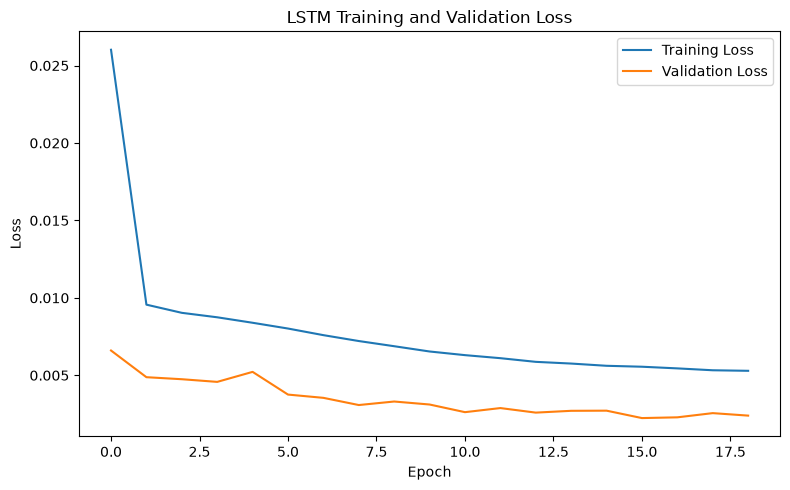

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
lstm_pred_scaled = lstm_model.predict(
    X_test_lstm
)

lstm_predictions = lstm_scaler.inverse_transform(
    lstm_pred_scaled
)

actual_traffic = lstm_scaler.inverse_transform(
    y_test_lstm
)

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [72]:
lstm_mae = mean_absolute_error(
    actual_traffic,
    lstm_predictions
)

lstm_r2 = r2_score(
    actual_traffic,
    lstm_predictions
)

print("LSTM Results")
print("MAE:", round(lstm_mae, 2))
print("R-squared:", round(lstm_r2, 4))

LSTM Results
MAE: 219.03
R-squared: 0.9742


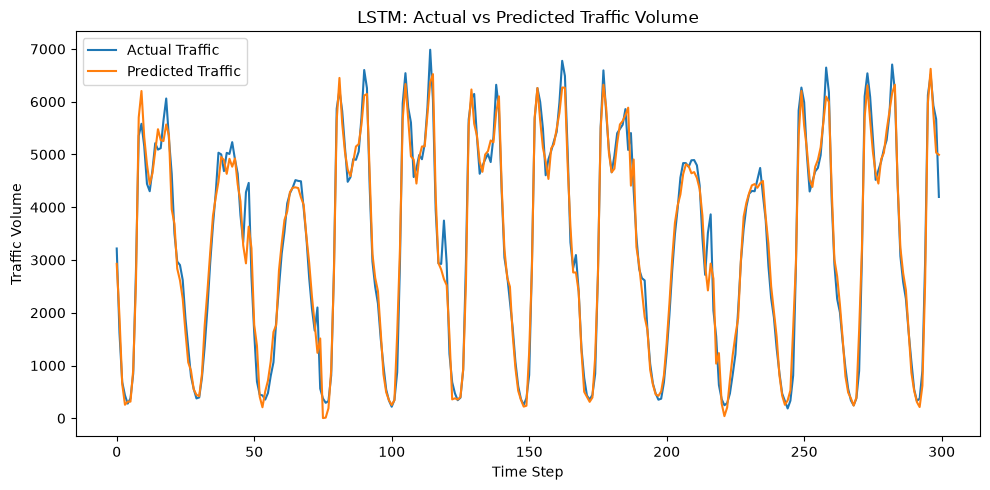

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(
    actual_traffic[:300],
    label="Actual Traffic"
)

plt.plot(
    lstm_predictions[:300],
    label="Predicted Traffic"
)

plt.xlabel("Time Step")
plt.ylabel("Traffic Volume")
plt.title("LSTM: Actual vs Predicted Traffic Volume")

plt.legend()
plt.tight_layout()
plt.show()

In [74]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)

In [75]:
lstm_model.save(
    "models/traffic_lstm.keras"
)

print("LSTM model saved.")

LSTM model saved.


C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=F

In [76]:
### SHAP Explainability

#Because the LSTM model is more complex to explain directly, SHAP is applied to a comparable Random Forest regression model
#trained on the same traffic-volume prediction problem.

%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [77]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [78]:
explainer = shap.TreeExplainer(
    rf_reg_model
)

In [79]:
X_shap = X_test_r.sample(
    n=min(1000, len(X_test_r)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

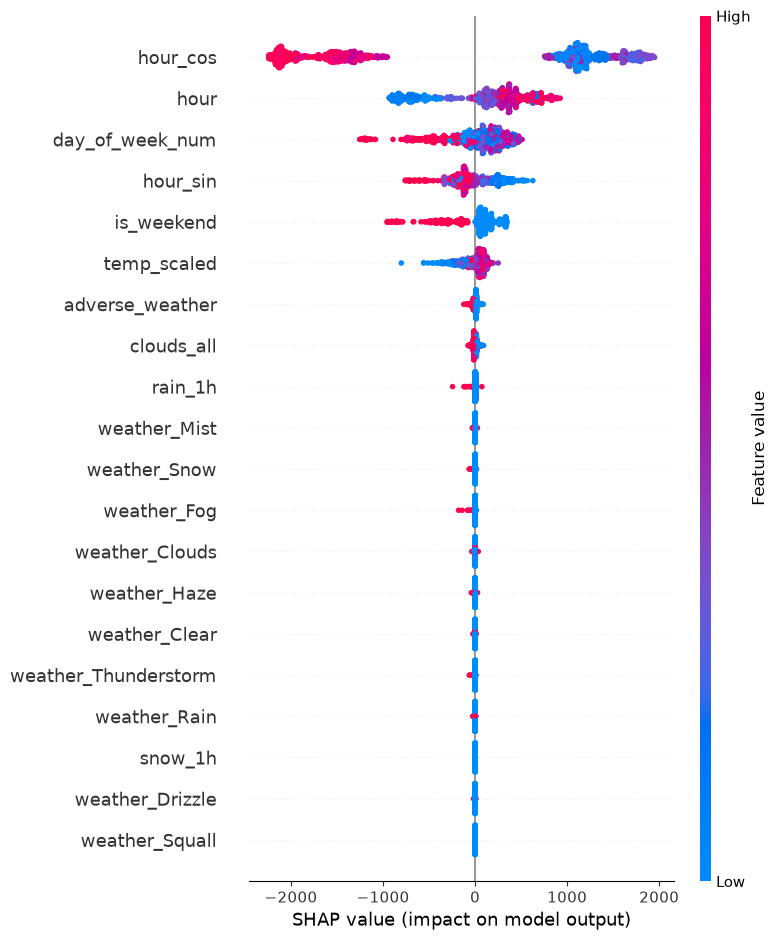

In [80]:
shap.summary_plot(
    shap_values,
    X_shap
)

In [81]:
## Task 4: Advanced AI Technique — MLflow Experiment Tracking

#MLflow was selected as the advanced AI technique because it provides a structured way to record and compare machine learning experiments.
#It also supports the later MLOps stage of the project by improving reproducibility and model management.

import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [82]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment(
    "Smart_City_Traffic_Models"
)

<Experiment: artifact_location=('file:C:/Users/hangz/OneDrive/Documents/P-KymPC/NUS Comp/Capstone/Capstone '
 'Part 2/mlruns/1'), creation_time=1790321716222, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790321716222, lifecycle_stage='active', name='Smart_City_Traffic_Models', tags={}, trace_location=None, workspace='default'>

In [91]:
with mlflow.start_run(
    run_name="Logistic_Regression_Classification"
):

    mlflow.log_param(
        "model_type",
        "Logistic Regression"
    )

    mlflow.log_param(
        "max_iter",
        2000
    )

    mlflow.log_param(
        "class_weight",
        "balanced"
    )

    mlflow.log_metric(
        "accuracy",
        log_accuracy
    )

    mlflow.log_metric(
        "precision",
        log_precision
    )

    mlflow.log_metric(
        "recall",
        log_recall
    )

    mlflow.log_metric(
        "f1_score",
        log_f1
    )

    mlflow.log_metric(
        "roc_auc",
        log_auc
    )

    mlflow.sklearn.log_model(
        log_model,
        name="logistic_regression_model"
    )

In [84]:
with mlflow.start_run(
    run_name="Random_Forest_Classification"
):

    mlflow.log_param(
        "model_type",
        "Random Forest Classifier"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "max_depth",
        10
    )

    mlflow.log_param(
        "class_weight",
        "balanced"
    )

    mlflow.log_metric(
        "accuracy",
        rf_accuracy
    )

    mlflow.log_metric(
        "precision",
        rf_precision
    )

    mlflow.log_metric(
        "recall",
        rf_recall
    )

    mlflow.log_metric(
        "f1_score",
        rf_f1
    )

    mlflow.log_metric(
        "roc_auc",
        rf_auc
    )

    mlflow.sklearn.log_model(
        rf_class_model,
        name="random_forest_classifier"
    )

In [85]:
with mlflow.start_run(
    run_name="Linear_Regression_Traffic"
):

    mlflow.log_param(
        "model_type",
        "Linear Regression"
    )

    mlflow.log_metric(
        "mae",
        linear_mae
    )

    mlflow.log_metric(
        "r2",
        linear_r2
    )

    mlflow.sklearn.log_model(
        linear_model,
        name="linear_regression_model"
    )

In [86]:
with mlflow.start_run(
    run_name="Random_Forest_Regression"
):

    mlflow.log_param(
        "model_type",
        "Random Forest Regressor"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "max_depth",
        10
    )

    mlflow.log_metric(
        "mae",
        rf_reg_mae
    )

    mlflow.log_metric(
        "r2",
        rf_reg_r2
    )

    mlflow.sklearn.log_model(
        rf_reg_model,
        name="random_forest_regressor"
    )

In [87]:
experiment = mlflow.get_experiment_by_name(
    "Smart_City_Traffic_Models"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

print("Number of MLflow runs:", len(runs))

Number of MLflow runs: 9


In [88]:
runs[
    [
        "tags.mlflow.runName",
        "params.model_type",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1_score",
        "metrics.roc_auc",
        "metrics.mae",
        "metrics.r2"
    ]
]

,tags.mlflow.runName,params.model_type,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.roc_auc,metrics.mae,metrics.r2
0,Random_Forest_Regression,Random Forest Regressor,NaN,NaN,NaN,NaN,NaN,266.720226,0.946923
1,Linear_Regression_Traffic,Linear Regression,NaN,NaN,NaN,NaN,NaN,820.382801,0.721971
2,Random_Forest_Classification,Random Forest Classifier,0.978626,0.908866,0.988153,0.946852,0.996863,NaN,NaN
3,Logistic_Regression_Classification,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302,NaN,NaN
4,Random_Forest_Regression,Random Forest Regressor,NaN,NaN,NaN,NaN,NaN,266.720226,0.946923
5,Linear_Regression_Traffic,Linear Regression,NaN,NaN,NaN,NaN,NaN,820.382801,0.721971
6,Random_Forest_Classification,Random Forest Classifier,0.978626,0.908866,0.988153,0.946852,0.996863,NaN,NaN
7,Logistic_Regression_Classification,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302,NaN,NaN
8,Logistic_Regression_Classification,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302,NaN,NaN


In [89]:
import mlflow
print(mlflow.__version__)
print(mlflow.__file__)

3.15.1
C:\Users\hangz\anaconda3\Lib\site-packages\mlflow\__init__.py


In [92]:
classification_mlflow = runs[
    runs["params.model_type"].isin(
        [
            "Logistic Regression",
            "Random Forest Classifier"
        ]
    )
][
    [
        "params.model_type",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1_score",
        "metrics.roc_auc"
    ]
]

classification_mlflow

,params.model_type,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.roc_auc
2,Random Forest Classifier,0.978626,0.908866,0.988153,0.946852,0.996863
3,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302
6,Random Forest Classifier,0.978626,0.908866,0.988153,0.946852,0.996863
7,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302
8,Logistic Regression,0.956526,0.822711,0.987076,0.897430,0.991302


In [93]:
regression_mlflow = runs[
    runs["params.model_type"].isin(
        [
            "Linear Regression",
            "Random Forest Regressor"
        ]
    )
][
    [
        "params.model_type",
        "metrics.mae",
        "metrics.r2"
    ]
]

regression_mlflow

,params.model_type,metrics.mae,metrics.r2
0,Random Forest Regressor,266.720226,0.946923
1,Linear Regression,820.382801,0.721971
4,Random Forest Regressor,266.720226,0.946923
5,Linear Regression,820.382801,0.721971


In [94]:
import mlflow.keras

with mlflow.start_run(
    run_name="LSTM_Traffic_Prediction"
):

    mlflow.log_param(
        "model_type",
        "LSTM"
    )

    mlflow.log_param(
        "sequence_length",
        24
    )

    mlflow.log_param(
        "lstm_units",
        50
    )

    mlflow.log_param(
        "batch_size",
        32
    )

    mlflow.log_metric(
        "mae",
        lstm_mae
    )

    mlflow.log_metric(
        "r2",
        lstm_r2
    )

    mlflow.keras.log_model(
        lstm_model,
        name="lstm_traffic_model"
    )

2026/09/25 15:49:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:172: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
C:\Users\hangz\anaconda3\Lib\site-packages\keras\src\backend\tenso

In [95]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

print("Number of MLflow runs:", len(runs))

Number of MLflow runs: 12


In [96]:
## Task 5: Traffic Recommendation System

#The recommendation system uses historical traffic patterns to identify suitable travel times.
#Since the dataset represents a single traffic corridor, the system recommends travel timing rather than alternative routes.

recommendation_df = df.copy()

recommendation_df["date_time"] = pd.to_datetime(
    recommendation_df["date_time"]
)

recommendation_df[
    ["date_time", "hour", "is_weekend",
     "adverse_weather", "traffic_volume"]
].head()

,date_time,hour,is_weekend,adverse_weather,traffic_volume
0,2012-10-02 09:00:00,9,0,0,5545
1,2012-10-02 10:00:00,10,0,0,4516
2,2012-10-02 11:00:00,11,0,0,4767
3,2012-10-02 12:00:00,12,0,0,5026
4,2012-10-02 13:00:00,13,0,0,4918


In [97]:
hourly_traffic = (
    recommendation_df
    .groupby("hour")["traffic_volume"]
    .mean()
    .reset_index()
    .sort_values("traffic_volume")
)

hourly_traffic.round(2)

,hour,traffic_volume
3,3,371.09
2,2,388.35
1,1,516.34
4,4,702.55
0,0,834.98
23,23,1469.14
5,5,2094.57
22,22,2199.41
21,21,2668.94
20,20,2834.67


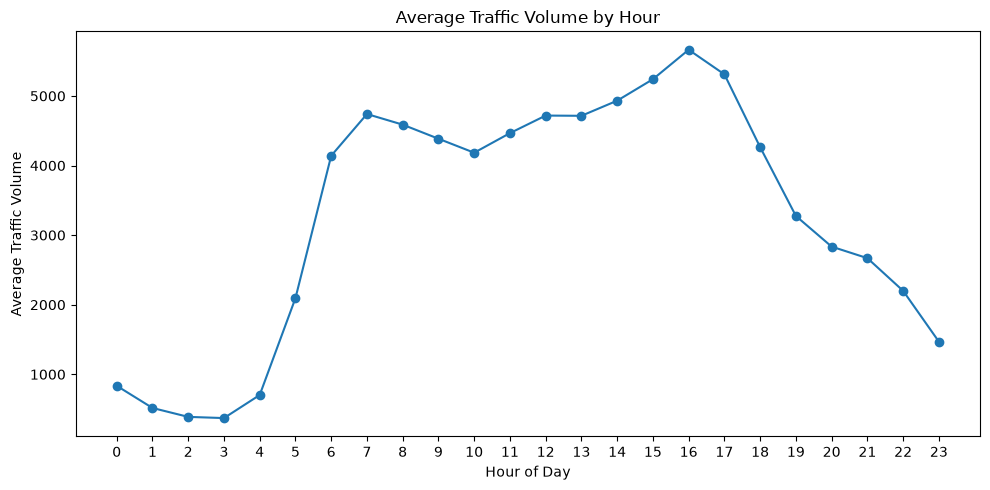

In [98]:
hourly_plot = (
    recommendation_df
    .groupby("hour")["traffic_volume"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_plot.index,
    hourly_plot.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [99]:
recommendation_df["day_type"] = (
    recommendation_df["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

In [100]:
day_hour_traffic = (
    recommendation_df
    .groupby(["day_type", "hour"])["traffic_volume"]
    .mean()
    .reset_index()
)

day_hour_traffic.head()

,day_type,hour,traffic_volume
0,Weekday,0,651.686903
1,Weekday,1,396.913043
2,Weekday,2,301.982818
3,Weekday,3,362.289835
4,Weekday,4,832.661096


In [101]:
best_hours_by_day = (
    day_hour_traffic
    .sort_values(
        ["day_type", "traffic_volume"]
    )
    .groupby("day_type")
    .head(5)
)

best_hours_by_day.round(2)

,day_type,hour,traffic_volume
2,Weekday,2,301.98
3,Weekday,3,362.29
1,Weekday,1,396.91
0,Weekday,0,651.69
4,Weekday,4,832.66
28,Weekend,4,375.42
27,Weekend,3,393.61
26,Weekend,2,611.17
29,Weekend,5,639.24
25,Weekend,1,805.72


In [102]:
recommendation_df["weather_type"] = (
    recommendation_df["adverse_weather"]
    .map({
        0: "Normal",
        1: "Adverse"
    })
)

In [103]:
travel_patterns = (
    recommendation_df
    .groupby(
        ["day_type", "weather_type", "hour"]
    )["traffic_volume"]
    .agg(["mean", "count"])
    .reset_index()
)

travel_patterns.columns = [
    "day_type",
    "weather_type",
    "hour",
    "avg_traffic",
    "records"
]

travel_patterns.head()

,day_type,weather_type,hour,avg_traffic,records
0,Weekday,Adverse,0,639.921191,571
1,Weekday,Adverse,1,387.728785,601
2,Weekday,Adverse,2,298.926282,624
3,Weekday,Adverse,3,361.077961,667
4,Weekday,Adverse,4,842.583454,689


In [104]:
def recommend_travel_time(
    day_type,
    weather_type
):
    filtered = travel_patterns[
        (travel_patterns["day_type"] == day_type) &
        (travel_patterns["weather_type"] == weather_type)
    ].copy()

    # Keep hours with a reasonable amount of historical data
    filtered = filtered[
        filtered["records"] >= 20
    ]

    if filtered.empty:
        return None

    best = filtered.sort_values(
        "avg_traffic"
    ).iloc[0]

    return {
        "day_type": day_type,
        "weather_type": weather_type,
        "hour": int(best["hour"]),
        "avg_traffic": round(
            best["avg_traffic"], 2
        ),
        "records": int(best["records"])
    }

In [105]:
weekday_recommendation = recommend_travel_time(
    "Weekday",
    "Normal"
)

weekday_recommendation

{'day_type': 'Weekday',
 'weather_type': 'Normal',
 'hour': 2,
 'avg_traffic': np.float64(304.28),
 'records': 831}

In [106]:
from datetime import datetime

def format_hour(hour):
    return datetime.strptime(
        str(hour),
        "%H"
    ).strftime("%I:%M %p")

In [107]:
print(format_hour(10))
print(format_hour(17))

10:00 AM
05:00 PM


In [108]:
def generate_recommendation(
    day_type,
    weather_type
):
    result = recommend_travel_time(
        day_type,
        weather_type
    )

    if result is None:
        return (
            "There is not enough historical data "
            "to make a recommendation."
        )

    start_hour = result["hour"]
    end_hour = (start_hour + 1) % 24

    start_text = format_hour(start_hour)
    end_text = format_hour(end_hour)

    recommendation = (
        f"For a {day_type.lower()} journey during "
        f"{weather_type.lower()} weather, consider "
        f"travelling between {start_text} and "
        f"{end_text}. Historical traffic volume "
        f"during this period averaged approximately "
        f"{result['avg_traffic']:.0f} vehicles."
    )

    return recommendation

In [109]:
print(
    generate_recommendation(
        "Weekday",
        "Normal"
    )
)

For a weekday journey during normal weather, consider travelling between 02:00 AM and 03:00 AM. Historical traffic volume during this period averaged approximately 304 vehicles.


In [110]:
print(
    generate_recommendation(
        "Weekend",
        "Normal"
    )
)

For a weekend journey during normal weather, consider travelling between 04:00 AM and 05:00 AM. Historical traffic volume during this period averaged approximately 384 vehicles.


In [111]:
print(
    generate_recommendation(
        "Weekday",
        "Adverse"
    )
)

For a weekday journey during adverse weather, consider travelling between 02:00 AM and 03:00 AM. Historical traffic volume during this period averaged approximately 299 vehicles.


In [112]:
scenarios = [
    ("Weekday", "Normal"),
    ("Weekday", "Adverse"),
    ("Weekend", "Normal"),
    ("Weekend", "Adverse")
]

recommendation_results = []

for day, weather in scenarios:
    result = recommend_travel_time(
        day,
        weather
    )

    if result is not None:
        recommendation_results.append(
            {
                "Day Type": day,
                "Weather": weather,
                "Recommended Hour": result["hour"],
                "Average Traffic": result["avg_traffic"],
                "Historical Records": result["records"]
            }
        )

recommendation_table = pd.DataFrame(
    recommendation_results
)

recommendation_table

,Day Type,Weather,Recommended Hour,Average Traffic,Historical Records
0,Weekday,Normal,2,304.28,831
1,Weekday,Adverse,2,298.93,624
2,Weekend,Normal,4,383.86,334
3,Weekend,Adverse,4,364.62,261


In [113]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

recommendation_table.to_csv(
    "outputs/travel_recommendations.csv",
    index=False
)

In [114]:
## Task 6: MLOps and Deployment Simulation

### 6.1 Model Versioning

#Different model versions and their evaluation results are documented to support comparison, reproducibility and future deployment decisions.

model_versions = pd.DataFrame({
    "Version": [
        "v1",
        "v2",
        "v3"
    ],
    "Model": [
        "Linear Regression",
        "Random Forest Regression",
        "LSTM"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae,
        lstm_mae
    ],
    "R-squared": [
        linear_r2,
        rf_reg_r2,
        lstm_r2
    ]
})

model_versions.round(4)

,Version,Model,MAE,R-squared
0,v1,Linear Regression,820.3828,0.7220
1,v2,Random Forest Regression,266.7202,0.9469
2,v3,LSTM,219.0291,0.9742


In [115]:
import mlflow

experiment = mlflow.get_experiment_by_name(
    "Smart_City_Traffic_Models"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs[
    [
        "tags.mlflow.runName",
        "params.model_type",
        "metrics.mae",
        "metrics.r2"
    ]
]

,tags.mlflow.runName,params.model_type,metrics.mae,metrics.r2
0,LSTM_Traffic_Prediction,LSTM,219.029100,0.974219
1,Logistic_Regression_Classification,Logistic Regression,NaN,NaN
2,Logistic_Regression_Classification,Logistic Regression,NaN,NaN
3,Random_Forest_Regression,Random Forest Regressor,266.720226,0.946923
4,Linear_Regression_Traffic,Linear Regression,820.382801,0.721971
5,Random_Forest_Classification,Random Forest Classifier,NaN,NaN
6,Logistic_Regression_Classification,Logistic Regression,NaN,NaN
7,Random_Forest_Regression,Random Forest Regressor,266.720226,0.946923
8,Linear_Regression_Traffic,Linear Regression,820.382801,0.721971
9,Random_Forest_Classification,Random Forest Classifier,NaN,NaN


In [116]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

joblib.dump(
    rf_reg_model,
    "models/random_forest_regression.pkl"
)

['models/random_forest_regression.pkl']

In [117]:
joblib.dump(
    regression_features,
    "models/regression_features.pkl"
)

['models/regression_features.pkl']

In [118]:
import flask

print(flask.__version__)

3.1.2


C:\Users\hangz\AppData\Local\Temp\ipykernel_2032\4274832069.py:3: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(flask.__version__)


In [123]:
sample_input = X_test_r.iloc[0]

sample_input

hour                    13.000000
day_of_week_num          1.000000
is_weekend               0.000000
hour_sin                -0.258819
hour_cos                -0.965926
temp_scaled              0.384673
rain_1h                  0.000000
snow_1h                  0.000000
clouds_all              90.000000
adverse_weather          0.000000
weather_Clear            0.000000
weather_Clouds           1.000000
weather_Drizzle          0.000000
weather_Fog              0.000000
weather_Haze             0.000000
weather_Mist             0.000000
weather_Rain             0.000000
weather_Smoke            0.000000
weather_Snow             0.000000
weather_Squall           0.000000
weather_Thunderstorm     0.000000
Name: 1162, dtype: float64

In [124]:
sample_input.to_dict()

{'hour': 13.0,
 'day_of_week_num': 1.0,
 'is_weekend': 0.0,
 'hour_sin': -0.2588190451025208,
 'hour_cos': -0.9659258262890684,
 'temp_scaled': 0.3846730653869231,
 'rain_1h': 0.0,
 'snow_1h': 0.0,
 'clouds_all': 90.0,
 'adverse_weather': 0.0,
 'weather_Clear': 0.0,
 'weather_Clouds': 1.0,
 'weather_Drizzle': 0.0,
 'weather_Fog': 0.0,
 'weather_Haze': 0.0,
 'weather_Mist': 0.0,
 'weather_Rain': 0.0,
 'weather_Smoke': 0.0,
 'weather_Snow': 0.0,
 'weather_Squall': 0.0,
 'weather_Thunderstorm': 0.0}

In [125]:
import requests

sample_data = (
    X_test_r
    .iloc[0]
    .to_dict()
)

response = requests.post(
    "http://127.0.0.1:5001/predict",
    json=sample_data
)

response.json()

{'predicted_traffic_volume': 4691.0}

In [126]:
baseline_mae = rf_reg_mae

print(
    "Baseline MAE:",
    round(baseline_mae, 2)
)

Baseline MAE: 266.72


In [127]:
monitor_size = min(
    1000,
    len(X_test_r)
)

X_monitor = X_test_r.iloc[:monitor_size]
y_monitor = y_test_r.iloc[:monitor_size]

monitor_predictions = rf_reg_model.predict(
    X_monitor
)

monitor_mae = mean_absolute_error(
    y_monitor,
    monitor_predictions
)

print(
    "Monitoring MAE:",
    round(monitor_mae, 2)
)

Monitoring MAE: 252.98


In [129]:
alert_threshold = baseline_mae * 1.20

print(
    "Alert Threshold:",
    round(alert_threshold, 2)
)

Alert Threshold: 320.06


In [130]:
if monitor_mae <= alert_threshold:
    monitoring_status = "PASS / Normal"
else:
    monitoring_status = "ALERT / Requires investigation"

print(
    "System Status:",
    monitoring_status
)

System Status: PASS / Normal


In [131]:
np.random.seed(42)

drifted_predictions = (
    monitor_predictions +
    np.random.normal(
        0,
        baseline_mae * 2,
        size=len(monitor_predictions)
    )
)

drifted_mae = mean_absolute_error(
    y_monitor,
    drifted_predictions
)

if drifted_mae <= alert_threshold:
    drift_status = "PASS / Normal"
else:
    drift_status = "ALERT / Requires investigation"

print(
    "Baseline MAE:",
    round(baseline_mae, 2)
)

print(
    "Drifted MAE:",
    round(drifted_mae, 2)
)

print(
    "Alert Threshold:",
    round(alert_threshold, 2)
)

print(
    "Drift Status:",
    drift_status
)

Baseline MAE: 266.72
Drifted MAE: 508.18
Alert Threshold: 320.06
Drift Status: ALERT / Requires investigation


In [139]:
fairness_check = (
    df.groupby(
        ["is_weekend", "adverse_weather"]
    )
    .size()
    .reset_index(name="Number of Records")
)

fairness_check["Day Type"] = (
    fairness_check["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

fairness_check["Weather"] = (
    fairness_check["adverse_weather"]
    .map({
        0: "Normal",
        1: "Adverse"
    })
)

fairness_check[
    [
        "Day Type",
        "Weather",
        "Number of Records"
    ]
]

,Day Type,Weather,Number of Records
0,Weekday,Normal,21195
1,Weekday,Adverse,13292
2,Weekend,Normal,8727
3,Weekend,Adverse,4973


In [140]:
error_analysis = X_test_r.copy()

error_analysis["Actual"] = y_test_r
error_analysis["Predicted"] = rf_reg_pred

error_analysis["Absolute_Error"] = abs(
    error_analysis["Actual"] -
    error_analysis["Predicted"]
)

error_analysis["Day_Type"] = (
    error_analysis["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

error_analysis["Weather_Type"] = (
    error_analysis["adverse_weather"]
    .map({
        0: "Normal",
        1: "Adverse"
    })
)

In [141]:
error_by_condition = (
    error_analysis
    .groupby(
        ["Day_Type", "Weather_Type"]
    )["Absolute_Error"]
    .agg(["mean", "count"])
    .reset_index()
)

error_by_condition.columns = [
    "Day Type",
    "Weather",
    "MAE",
    "Number of Records"
]

error_by_condition.round(2)

,Day Type,Weather,MAE,Number of Records
0,Weekday,Adverse,263.74,2671
1,Weekday,Normal,270.79,4256
2,Weekend,Adverse,259.16,971
3,Weekend,Normal,265.57,1740
